**Projet ISD2 final:** Analyse d'une base de données Formule 1! (2000-2024)

**Partie 1 : Prétraitement** 

In [22]:
# importation des bibiliothéques nécéssaires au projet 
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, ceil

In [23]:
# chargement des fichiers de source

Data_Dir = "DataSet_F1"                                 # pointe vers le fichier source du répositoire
Output = "DataSet_F1_Final"        
NA_VALUES = ["//N", ""] # nom du fichier complet

In [24]:
def load_csv(csv_file_name):
    file_path = os.path.join(Data_Dir, csv_file_name)
    return pd.read_csv(file_path, na_values = NA_VALUES)


In [25]:
def calculate_age(date_of_birth, current_year = 2026):
    year_of_birth = int(date_of_birth[:4])
    return current_year - year_of_birth

In [26]:
results           = load_csv("results.csv")
races             = load_csv("races.csv")
circuits          = load_csv("circuits.csv")
constructors      = load_csv("constructors.csv")
status            = load_csv("status.csv")
qualifying        = load_csv("qualifying.csv")
pit_stops         = load_csv("pit_stops.csv")
driver_standings  = load_csv("driver_standings.csv")
lap_times         = load_csv("lap_times.csv")
drivers           = load_csv("drivers.csv")

drivers["driver_name"] = drivers["forename"] + " " + drivers["surname"]
drivers["driver_age"] = drivers["dob"].apply(calculate_age)

pit_agg = pit_stops.groupby(["raceId", "driverId"]).agg(best_lap_ms = ("milliseconds", "min"), lap_std_ms = ("milliseconds", "std")).reset_index()
pits_aux  = pit_stops.groupby(["raceId", "driverId"]).count().reset_index()
pit_agg["pit_stop_count"] = pits_aux["stop"]



df = results.copy()
df = df.merge(races[["raceId", "year", "round", "circuitId", "date"]], on = "raceId", how = "left")
df = df.merge(circuits[["circuitId", "country", "name"]].rename(columns = {"name" : "circuit_name"}), on = "circuitId", how = "left")
df = df.merge(drivers[["driverId", "driver_age","driver_name" ]], on = "driverId", how = "left")
df = df.merge(constructors[["constructorId", "name"]].rename(columns = {"name" : "constructor_name"}), on = "constructorId", how = "left")
df = df.merge(status.rename(columns = {"status": "status_label"}), on = "statusId", how = "left")
df = df.merge(pit_agg, on = ["raceId", "driverId"], how = "left")
df["pit_stop_count"] = df["pit_stop_count"].fillna(0)
df = df.astype({"pit_stop_count" : "int32"})
# on renomme chacune des colonnes(optionel mais pratique)

df = df.rename(columns = {
    "grid":         "grid_position",
    "positionOrder":  "finish_position",
    "points":       "points_scored",
    "laps":         "laps_completed",
    "status_label": "status",
    "country":      "circuit_country",
    "rank":         "fastest_lap_rank",
    
})

# choix de nos features -> 14 en total 

features = [
    "year",                                     
    "round", 
    "grid_position", 
    "finish_position",
    "points_scored",
    "laps_completed",
    "status",
    "constructor_name",
    "circuit_country",
    "circuit_name",
    "driver_name",
    "driver_age",
    "pit_stop_count",
    "fastest_lap_rank",
]

df_features = features

df = df[features]
df = df[df["year"].between(2012, 2024)]        # reduit le nombre de lignes: passage de 1950-2024 à 2012-2024


df.to_csv(Output, index = False)

#visualistation des données

In [27]:
df.corr(numeric_only=True)["finish_position"]

year              -0.078926
round             -0.007109
grid_position      0.576891
finish_position    1.000000
points_scored     -0.836094
laps_completed    -0.486139
driver_age        -0.044530
pit_stop_count    -0.138483
Name: finish_position, dtype: float64

A première vue on dirait qu'il n'y a pas vraiment d'attribut en corrélation
directe avec la position finale du pilote à part :

    - la position de depart "grid_position"
    - le nombre de tours "laps_completed"
    - le nombre d'arrets au stand "pit_stop_count" 
    - le nombre de points obtenues "points_scored"

Mais dans ce cas le nombre de points est à exclure car il est en association directe de la position finale de la voiture.
Ainsi nous **sélectionnons les trois attributs par filtrage ("grid_position", "laps_completed", "pit_stop_count")**

In [28]:
def calcule_dimensions_subplot(attributs):
    nombre_attributs = len(attributs)
    side = int(ceil(sqrt(nombre_attributs) ))
    return side, side

def calcule_subplot_index(index, width):
    y = index // width
    x = index % width
    return x , y
    
def affiche_graphiques(attributs, dataframe = df,chart_width = 7,chart_height = 7, y_axis = "finish_position"):
    plot_width, plot_height = calcule_dimensions_subplot(attributs)
    fig , axes = plt.subplots(plot_width, plot_height, squeeze=False)
    fig.set_size_inches(plot_width * chart_width, plot_height * chart_height)
    
    for i, attribut in enumerate(attributs):
        x, y = calcule_subplot_index(i, plot_width)
        plot = axes[y,x]
        plot.set_title(f"{attribut} vs {y_axis}")
        plot.scatter(dataframe[attribut], df[y_axis])
        plot.set_ylabel(f"{y_axis}")
        plot.set_xlabel(f"{attribut}")


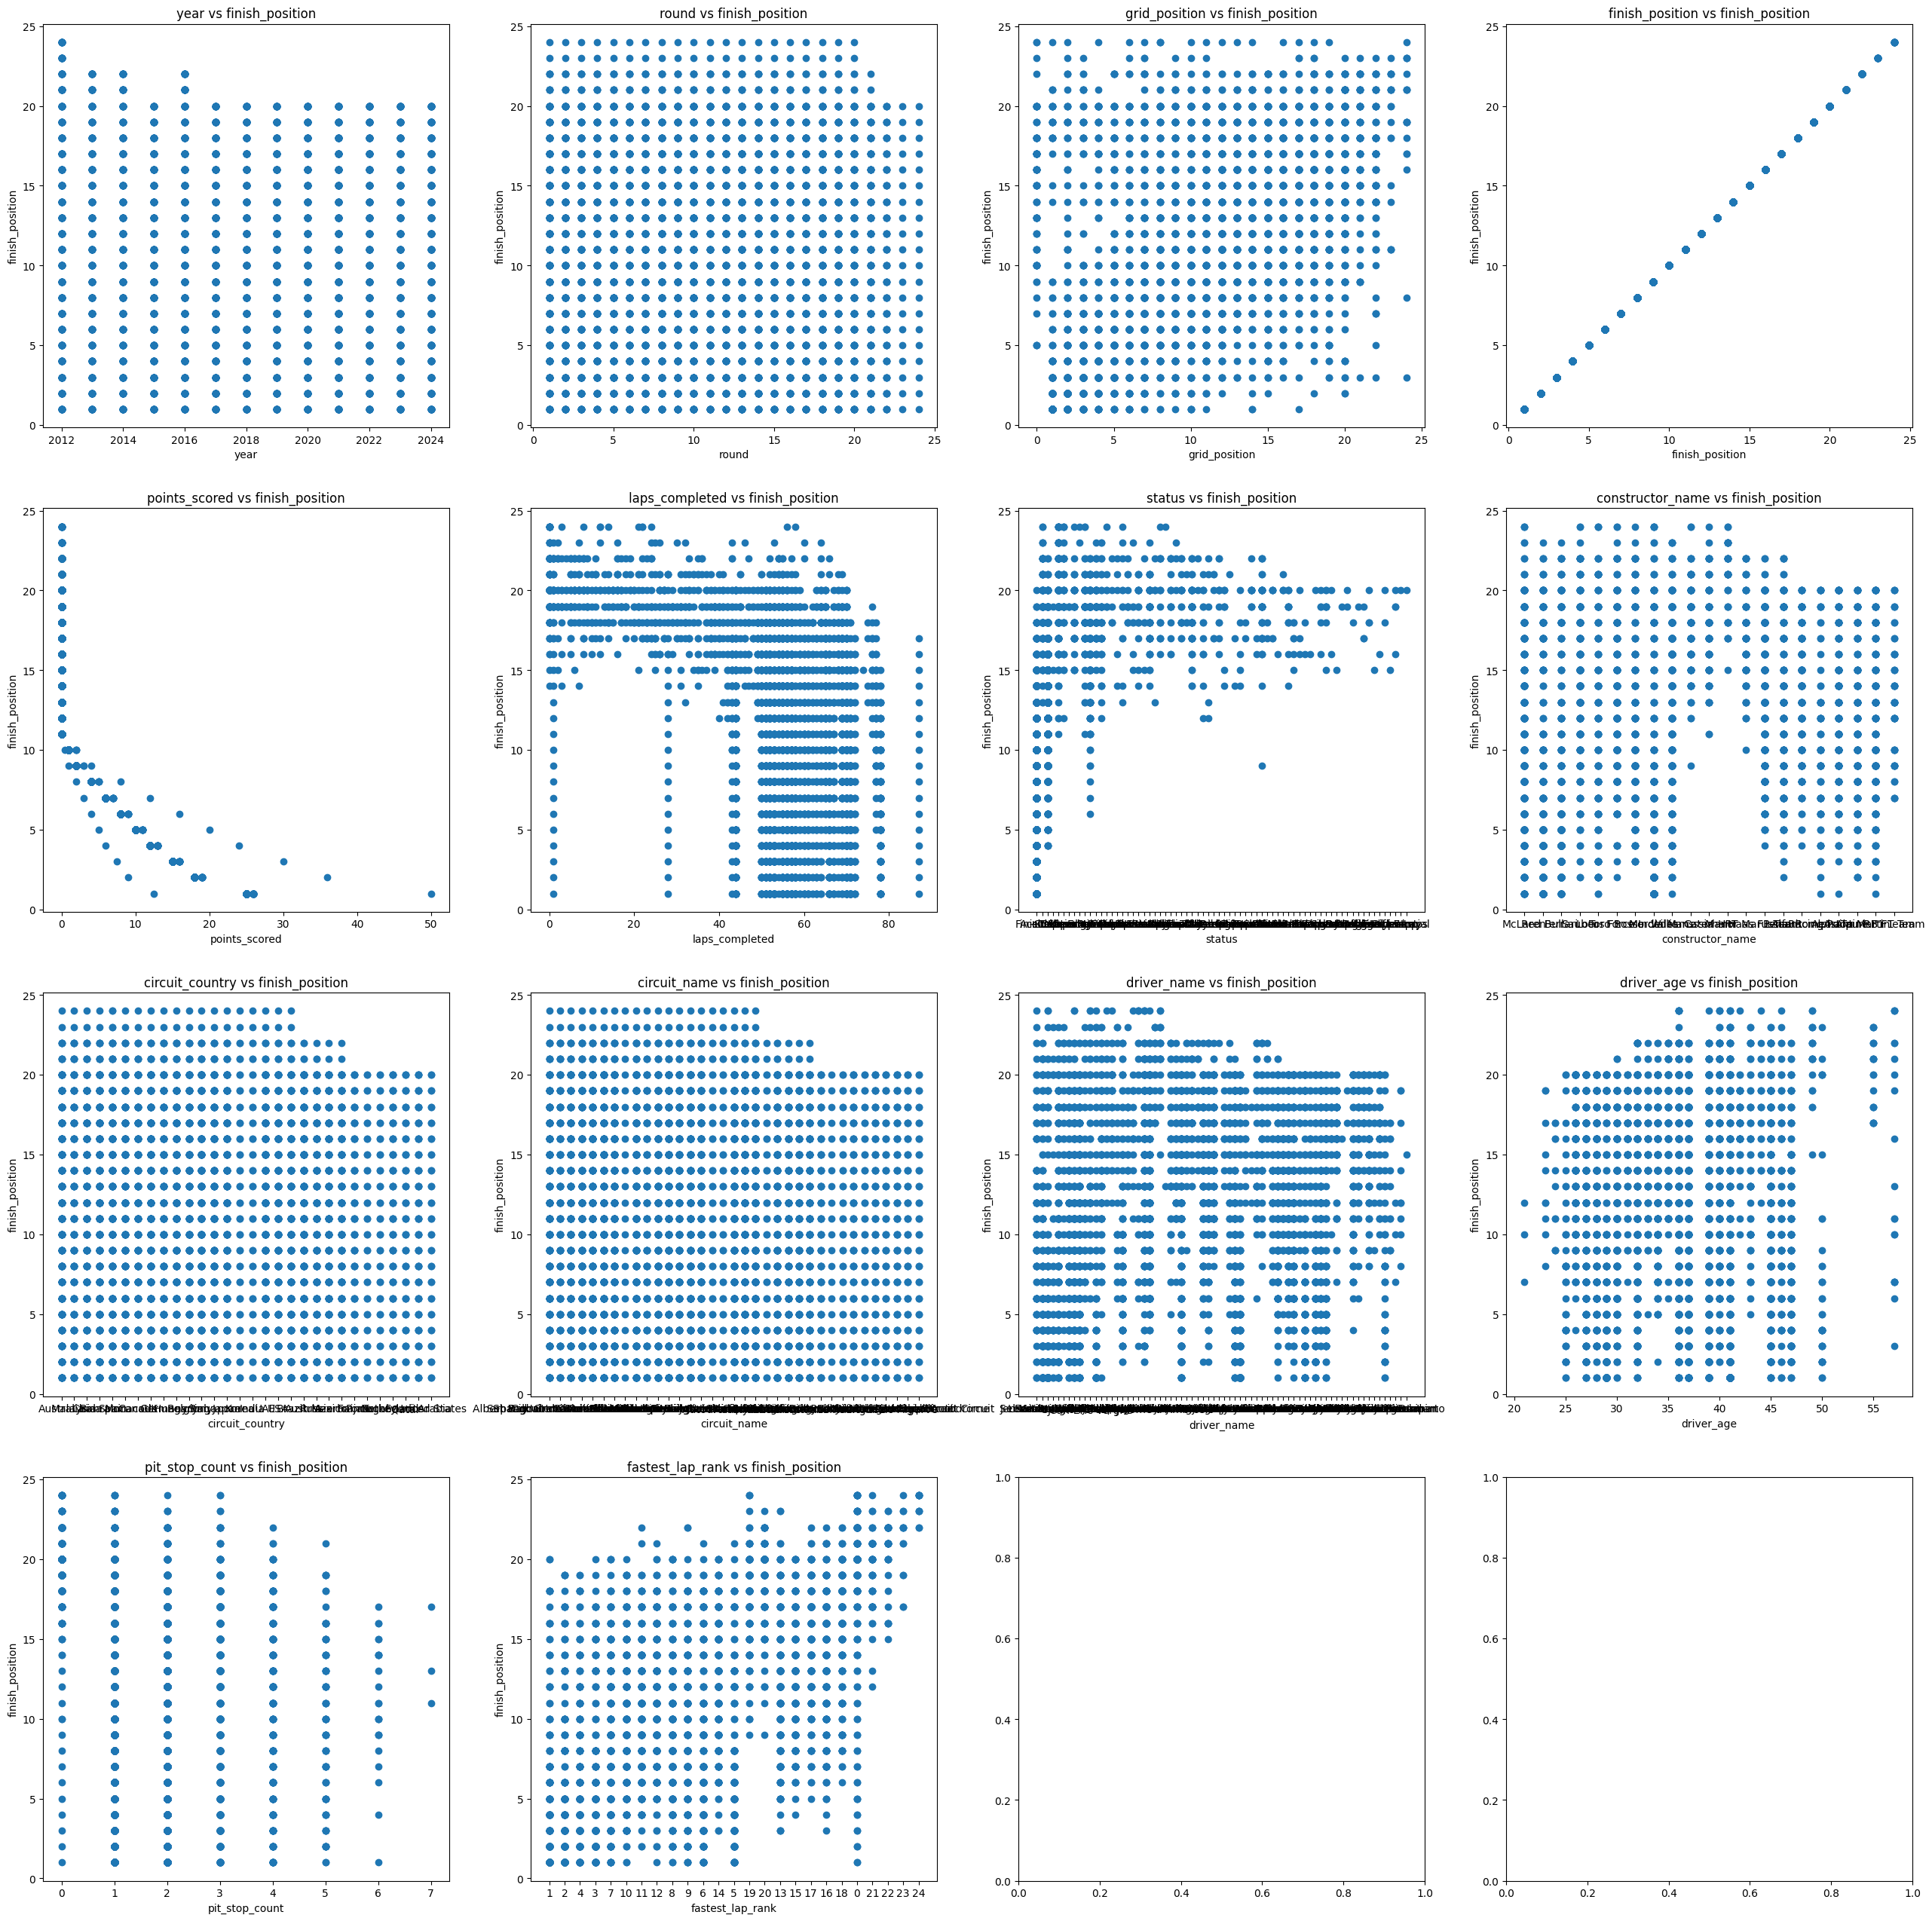

In [29]:
affiche_graphiques(df.columns, chart_width = 8, chart_height = 8)

On laisse la place pour la visualisation

**Idée**: On essaie de **calculer un coefficient avec les attributs grid_position , laps_completed et pit_stop, pour essayer de les morpher sous une seule feature**.
On réalise ceci en leur associant un poids donnée , et l'on essaie de voir si en fonction des poids choisis on peut obtenir des informations révélatrices sur le position finale.


In [30]:
df_coeffs = df.copy()
attribut_matrix = df_coeffs[["grid_position","laps_completed","pit_stop_count"]].to_numpy()

columns_to_delete = list(df_coeffs.columns)
columns_to_delete.remove("finish_position")
df_coeffs.drop(columns = columns_to_delete, inplace = True)

pourcentage_step = 5

for coeff_grid_position in range(0, 101 , pourcentage_step):
    for coeff_laps_comp in range (0, 101 - coeff_grid_position, pourcentage_step):
        cf_grid_pos = .01 * coeff_grid_position
        cf_laps_comp = .01 * coeff_laps_comp
        cf_pit_stop  = 1.0 - cf_grid_pos - cf_laps_comp
        matrix_coeff = np.asarray([cf_grid_pos, cf_laps_comp, cf_pit_stop])
        matrix_coeff = matrix_coeff.reshape(3, 1)
    
        df_coeffs[f"(cf_grid={cf_grid_pos}, cf_laps={cf_laps_comp}, cf_pit={cf_pit_stop})"] = np.dot(attribut_matrix, matrix_coeff)


/tmp/ipykernel_60171/3009037705.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_coeffs[f"(cf_grid={cf_grid_pos}, cf_laps={cf_laps_comp}, cf_pit={cf_pit_stop})"] = np.dot(attribut_matrix, matrix_coeff)


In [31]:
correlations = df_coeffs.corr(numeric_only=True)["finish_position"].drop(["finish_position"])
meilleure_correlation_positive = max(correlations)
meilleure_correlation_negative = min(correlations)
meilleure_correlation = max(meilleure_correlation_positive, abs(meilleure_correlation_negative))

print(f"la meilleure corrélation avec cette méthode est de {meilleure_correlation}")

la meilleure corrélation avec cette méthode est de 0.5768913319342104


In [ ]:
affiche_graphiques(df_coeffs.columns, df_coeffs) 

Etant donné que le fait de fusionner les attributs ne nous a pas permis d'obtenir une
corrélation plus avantageuse que les attributs dans leur état naturel, nous décidons de 
rester sur les trois attributs initiaux : **"grid_position", "laps_completed" et "pit_stop_count"**

**Partie 2: Modélisation**

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['grid_position',  'pit_stop_count', 'laps_completed']].fillna(0)

y = df['finish_position']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Données d'apprentissage : {X_train.shape[0]} courses")
print(f" Données de test : {X_test.shape[0]} courses")

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# REGRESSION LINEAIRE
modele_lr = LinearRegression()
modele_lr.fit(X_train, y_train)

predictions_lr = modele_lr.predict(X_test)
r2_lr = r2_score(y_test, predictions_lr) * 100

print(f" precision : {r2_lr:.1f} %")

In [ ]:
# RANDOM FOREST
modele_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modele_rf.fit(X_train, y_train)

predictions_rf = modele_rf.predict(X_test)
r2_rf = r2_score(y_test, predictions_rf) * 100

print(f"  • Précision : {r2_rf:.1f}%")

on remarque que le random forest est plus performant

In [ ]:
importances = modele_rf.feature_importances_
features_noms = X.columns

print(" Importance de nos 3 critères sélectionnés :\n")
for nom, valeur in zip(features_noms, importances):
    print(f" {nom} : {valeur * 100:.1f}%")

In [ ]:
resultats_comparaison = X_test.copy()
resultats_comparaison['Vraie_Position'] = y_test
resultats_comparaison['Position_Predite_IA'] = np.round(predictions_rf).astype(int)

# On affiche un échantillon des 5 premières courses pour voir les prédictions
print(" Comparaison des résultats réels vs prédictions de l'IA :")
print(resultats_comparaison[['grid_position', 'Vraie_Position', 'Position_Predite_IA']].head())

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(y_test.values[:50], label="Vrais Résultats", color="blue", marker="o", linestyle="")
plt.plot(predictions_rf[:50], label="Prédictions IA (Random Forest)", color="red", marker="x", linestyle="")

plt.title("Comparaison des 50 premiers résultats : Réel vs IA")
plt.xlabel("Index de la course dans le test")
plt.ylabel("Position finale")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# test de prediction

grid_position = 13   
laps_completed = 60  
pit_stop_count  = 4

simulation_pilote = [[grid_position, laps_completed , pit_stop_count]] 
prediction_simulation = modele_rf.predict(simulation_pilote)

print(f" Pour un pilote partant {grid_position}e avec {pit_stop_count} arrêts, l'IA prédit qu'il finira : {prediction_simulation[0]:.0f}e")

print( "verification du resultat: ")
courses_identiques = df[(df['grid_position'] == grid_position) & (df['pit_stop_count'] == pit_stop_count & (df['laps_completed'] >= laps_completed))]

if len(courses_identiques)>0:
    moyenne= courses_identiques['finish_position'].mean()
    print(f"• Dans l'historique, nous avons trouvé {len(courses_identiques)} courses avec ces critères.")
    print(f"• En réalité, ces pilotes ont fini en moyenne à la : {moyenne:.2f}e place.")

    ecart_validation = abs(prediction_simulation[0] - moyenne)
    print(f" Écart entre l'IA et la réalité historique : {ecart_validation:.0f} place.")
else:
    print("Aucun exemple identique exact trouvé dans l'historique. L'IA a donc combiné ses connaissances générales pour estimer ce résultat purement théorique.")


In [ ]:
#calcule de l'écart absolu entre la réalité et la prédiction
resultats_comparaison['Ecart'] = abs(resultats_comparaison['Vraie_Position'] - resultats_comparaison['Position_Predite_IA'])

#  les 5 plus grosses erreurs de l'IA
pires_erreurs = resultats_comparaison.sort_values(by='Ecart', ascending=False).head(5)

print(" LES 5 PLUS GROSSES ERREURS DE L'IA :")
print(pires_erreurs[['grid_position', 'laps_completed', 'pit_stop_count', 'Vraie_Position', 'Position_Predite_IA', 'Ecart']])

On commence par séparer les données de test en set d'entrainement et de test.
Dans ce cas ci on peut se passer des attributs en lien avec chaque conducteur, puisque l'on va réaliser la **prédiction en fonction des 3 attributs (grid_position ,laps_completed et pit_stop_count)**

In [ ]:
split_ratio = 0.7
split_index = int(len(df) * split_ratio)

attributs_pit_laps_grid = ["grid_position", "laps_completed", "pit_stop_count"]
attributs_full = df_features
attributs_full.remove("finish_position")

x_full = df[attributs_full]
y_full = df["finish_position"]

x_train = x_full[:split_index]
x_test = x_full[split_index:]
y_train = y_full[:split_index]
y_test = y_full[split_index:]

In [ ]:
def en_pourcentage(pourcentage):
    return f"{str(pourcentage * 100)}%"

In [ ]:
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(x_train[attributs_pit_laps_grid], y_train)
prediction_score_train_knn = knn.score(x_test[attributs_pit_laps_grid], y_test)
print(f"Sur l'ensemble des tests pour le KNN on a obtenu un taux de réussite de {en_pourcentage(prediction_score_train_knn)}")

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(x_train[attributs_pit_laps_grid], y_train)
prediction_score_train_dt = dt.score(x_test[attributs_pit_laps_grid], y_test)
print(f"Sur l'ensemble des tests pour le DecisionTreeClassifier on a obtenu un taux de réussite de {en_pourcentage(prediction_score_train_dt)}")

comme il est possible de le noter,le score d'une classification directement sur les données est médiocre. Il est bien trop dur de directement essayer de classifier la position de chaque voiture.

Mais pourquoi ne pas essayer de d'abord essayer de déterminer si la voiture se trouve dans une catégorie plus géneraliste : par exemple le top 5 et le top 15



In [ ]:
def predict_dans_top(position):
    y_train_binary = (y_train <= np.int64(position)).astype(int)
    y_test_binary = (y_test <= np.int64(position)).astype(int)
    
    logreg = LogisticRegression()
    logreg.fit(x_train[attributs_pit_laps_grid], y_train_binary)
    prediction_score_train_logreg = logreg.score(x_test[attributs_pit_laps_grid], y_test_binary)
    print(f"Top {position} ou non taux de réussite : {en_pourcentage(prediction_score_train_logreg)}")

In [ ]:
predict_dans_top(5)
predict_dans_top(15)

Nous voyons qu'on réussit plutôt bien a classifier si une voiture est dans un top ou non alors dans ce cas nous proposons l'algorithme suivant

Catégoriser les courses en différents tops : 5, 15 ou 20 . Et en fonction du top utiliser un algorithme spécifique sur cette course pour déterminer sa place

In [ ]:
def cree_predicteur_top(top, x_train, y_train):
    y_train_binary = (y_train <= np.int64(top)).astype(int)
    
    logreg = LogisticRegression()
    logreg.fit(x_train[attributs_pit_laps_grid], y_train_binary)
    return logreg
    
pred_top_5 = cree_predicteur_top(5,x_train, y_train)
pred_top_15 = cree_predicteur_top(15,x_train, y_train)

On crée des predicteurs spécialisés pour chaque sous ensemble engendré: 
- top 5
- top 15
- top 20

In [ ]:
def ajoute_colonne_top(data):
    def dans_top_5(row):
        row = pd.DataFrame(row).transpose().reset_index()
        if row["top_5"].all():
            return 5
        else :
            return row["top"][0]
            
    ## set the 15 top
    data["top"] = pd.Series(len(data))
    data["top"] = pred_top_15.predict(data[attributs_pit_laps_grid])
    data["top"] = data["top"].apply(lambda dans_top_15: 15 if dans_top_15 else 20)

    data["top_5"] = pred_top_5.predict(data[attributs_pit_laps_grid])
    data["top"] = data[["top", "top_5"]].apply(lambda x : dans_top_5(x), axis=1)
    
    data = data.drop(columns = ["top_5"])
    
    return data

In [ ]:
x_train = ajoute_colonne_top(x_train)

Maintenant on peut filtrer par top et créer les prédicteurs spécialisés à chacun des top

In [ ]:
def extract_x_train_top(top, data, attributs = attributs_pit_laps_grid):
    return data[data["top"] == top][attributs]

def extract_y_train_top(x, y): 
    return y[list(x.index)]

In [ ]:
# Encoding des variables catégorielles
enc_constructor = LabelEncoder()
enc_circuit = LabelEncoder()  
enc_driver = LabelEncoder()

x_full_copy = x_full.copy()
x_full = ajoute_colonne_top(x_full_copy)
x_full["constructor_name"] = enc_constructor.fit_transform(x_full["constructor_name"])
x_full["circuit_name"] = enc_circuit.fit_transform(x_full["circuit_name"])
x_full["driver_name"] = enc_driver.fit_transform(x_full["driver_name"])

x_train = x_full[:split_index]
x_test = x_full[split_index:]
y_train = y_full[:split_index]
y_test = y_full[split_index:]

pred_features = [
    "grid_position",
    "pit_stop_count", 
    "fastest_lap_rank",
    "points_scored",
    "driver_age",
    "laps_completed",
    "constructor_name",
    "circuit_name",
    "driver_name"
]

def cree_predicteur_pour_top(top, x, y, features):
    x_train_top = extract_x_train_top(top, x, features)
    y_train_top = extract_y_train_top(x_train_top, y)

    pred_special_top = RandomForestClassifier(n_estimators=100, random_state=42)
    pred_special_top.fit(x_train_top, y_train_top)

    return pred_special_top

In [ ]:
def prediction_par_dichotomie(row, predicteur_top_5, predicteur_top_15, predicteur_under_top_15):
    row = pd.DataFrame(row).transpose().reset_index()
    top = row["top"][0]
    
    if top >= 5:
        return predicteur_top_5.predict(row[pred_features])[0]
    elif top >= 15:
        return predicteur_top_15.predict(row[pred_features])[0]
    else :
        return predicteur_under_top_15.predict(row[pred_features])[0]

pred_top_5 = cree_predicteur_pour_top(5, x_train, y_train, pred_features)
pred_top_15 = cree_predicteur_pour_top(15, x_train, y_train, pred_features)
pred_top_20 = cree_predicteur_pour_top(20, x_train, y_train, pred_features)

**Partie 3: Evaluation**

In [ ]:
y_predicted = x_test.apply(lambda x: prediction_par_dichotomie(x, pred_top_5, pred_top_15,pred_top_20), axis=1)

In [ ]:
def evaluation_performance(predicted, correct):
    if (len(predicted) != len(correct)):
        raise Error("les series doivent avoir la meme taille")
    return en_pourcentage(sum(predicted == correct)/len(correct))

In [ ]:
score_prediction_precise = evaluation_performance(y_predicted, y_test)
print(f"On a une précision de {score_prediction_precise} !")

Il est plutôt complexe de classifier les données en leur position exacte mais l'on peut tout de même déterminer le podium !

In [ ]:
predicteur_podium = cree_predicteur_top(3,x_train, y_train)
y_predicted_podium = predicteur_podium.predict(x_test[attributs_pit_laps_grid])

y_test_podium = y_test <= 3

score_podium = evaluation_performance(y_predicted_podium, y_test_podium)
print(f"On a une précision de {score_podium} pour l'exactitude du podium !")